<a href="https://colab.research.google.com/github/melayusejati02/Agentic-AI-LinkedIn-Learning/blob/main/planning_autonomy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kena tambah OPEN AI KEY utk first time guna

In [1]:
# Setup for Colab vs Local
import os
import sys
import zipfile
import glob

# Check if running on Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Unzip the uploaded course files
    zip_path = '/content/agentic-ai-build-your-first-agentic-ai-system-4645038-main.zip'

    if os.path.exists(zip_path):
        print("Extracting course files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('/content/')
        print("✓ Course files extracted")
    else:
        raise FileNotFoundError(
            f"Please upload the course ZIP file to Colab first.\n"
            f"Expected location: {zip_path}\n"
            f"How to upload: Drag and drop the ZIP file into the Files panel (📁) on the left"
        )

    # Find the extracted directory (handles different ZIP structures)
    # Look for directories that contain 'assets' and 'data' folders
    possible_dirs = glob.glob('/content/agentic-ai-build-*/')
    course_dir = None

    for dir_path in possible_dirs:
        if os.path.exists(os.path.join(dir_path, 'assets')) and os.path.exists(os.path.join(dir_path, 'data')):
            course_dir = dir_path
            break

    if not course_dir:
        raise FileNotFoundError(
            "Could not find course directory after extraction.\n"
            "Please ensure the ZIP contains 'assets' and 'data' folders."
        )

    # Navigate to course directory
    os.chdir(course_dir)
    print(f"✓ Working directory: {os.getcwd()}")

    # Get API key from Colab secrets
    from google.colab import userdata
    os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
    print("✓ API key loaded from Colab secrets")
else:
    # Local environment - use .env file
    from dotenv import load_dotenv
    load_dotenv()

# Verify API key is set
if not os.getenv('OPENAI_API_KEY'):
    raise ValueError("Please set OPENAI_API_KEY in Colab Secrets or .env file")

print("\n" + "="*60)
print("Environment setup complete!")
print("="*60)

Extracting course files...
✓ Course files extracted
✓ Working directory: /content/agentic-ai-build-your-first-agentic-ai-system-4645038-main
✓ API key loaded from Colab secrets

Environment setup complete!


# V2: Planning Autonomy

## From Single Actions to Multi-Step Plans

In V1, we built an **action autonomy** agent that performed a single classification: routing customer messages to departments.

Now we move up the autonomy ladder to **planning autonomy**: generating multi-step action plans by retrieving relevant procedures and reasoning over them.

### What You'll Learn

1. **RAG Systems**: Use BM25 to retrieve relevant Standard Operating Procedures (SOPs)
2. **Multi-Step Planning**: Generate detailed action plans instead of single actions
3. **Custom Metrics**: Design evaluation metrics from observed failures
4. **LLM-as-Judge**: Use GPT-4o to evaluate GPT-5 outputs
5. **Trace-First Evaluation**: Observe → Discover → Measure → Improve

### The Incremental Building Story

**V1 Achievement:**
- Built routing from 73% → 93% accuracy
- Prompt 1 (baseline) → Prompt 2 (improved with descriptions)

**V2 Builds On V1:**
- **KEEPS** V1's 93% routing (don't regress!)
- **ADDS** BM25 retrieval to find relevant SOPs
- **ADDS** multi-step plan generation

**Key:** Each version builds on the previous one. We never start from scratch!

## V2 Architecture

Our V2 Planning Autonomy agent builds on V1's routing by adding retrieval and multi-step planning:





**Key Points:**
- **Green boxes** = V1 components (keep the 93% routing!)
- **Orange boxes** = V2 new components (BM25 + Planning)
- **Data flows** left-to-right: Message → Routing → Retrieval → Planning → Output

**What's New in V2:**
1. **BM25 Retriever**: Finds relevant SOPs using keyword matching
2. **Plan Generator**: Creates multi-step plans using retrieved context
3. **Custom Metrics**: SOP Recall + Plan Alignment (3-class)

V2 Architecture:


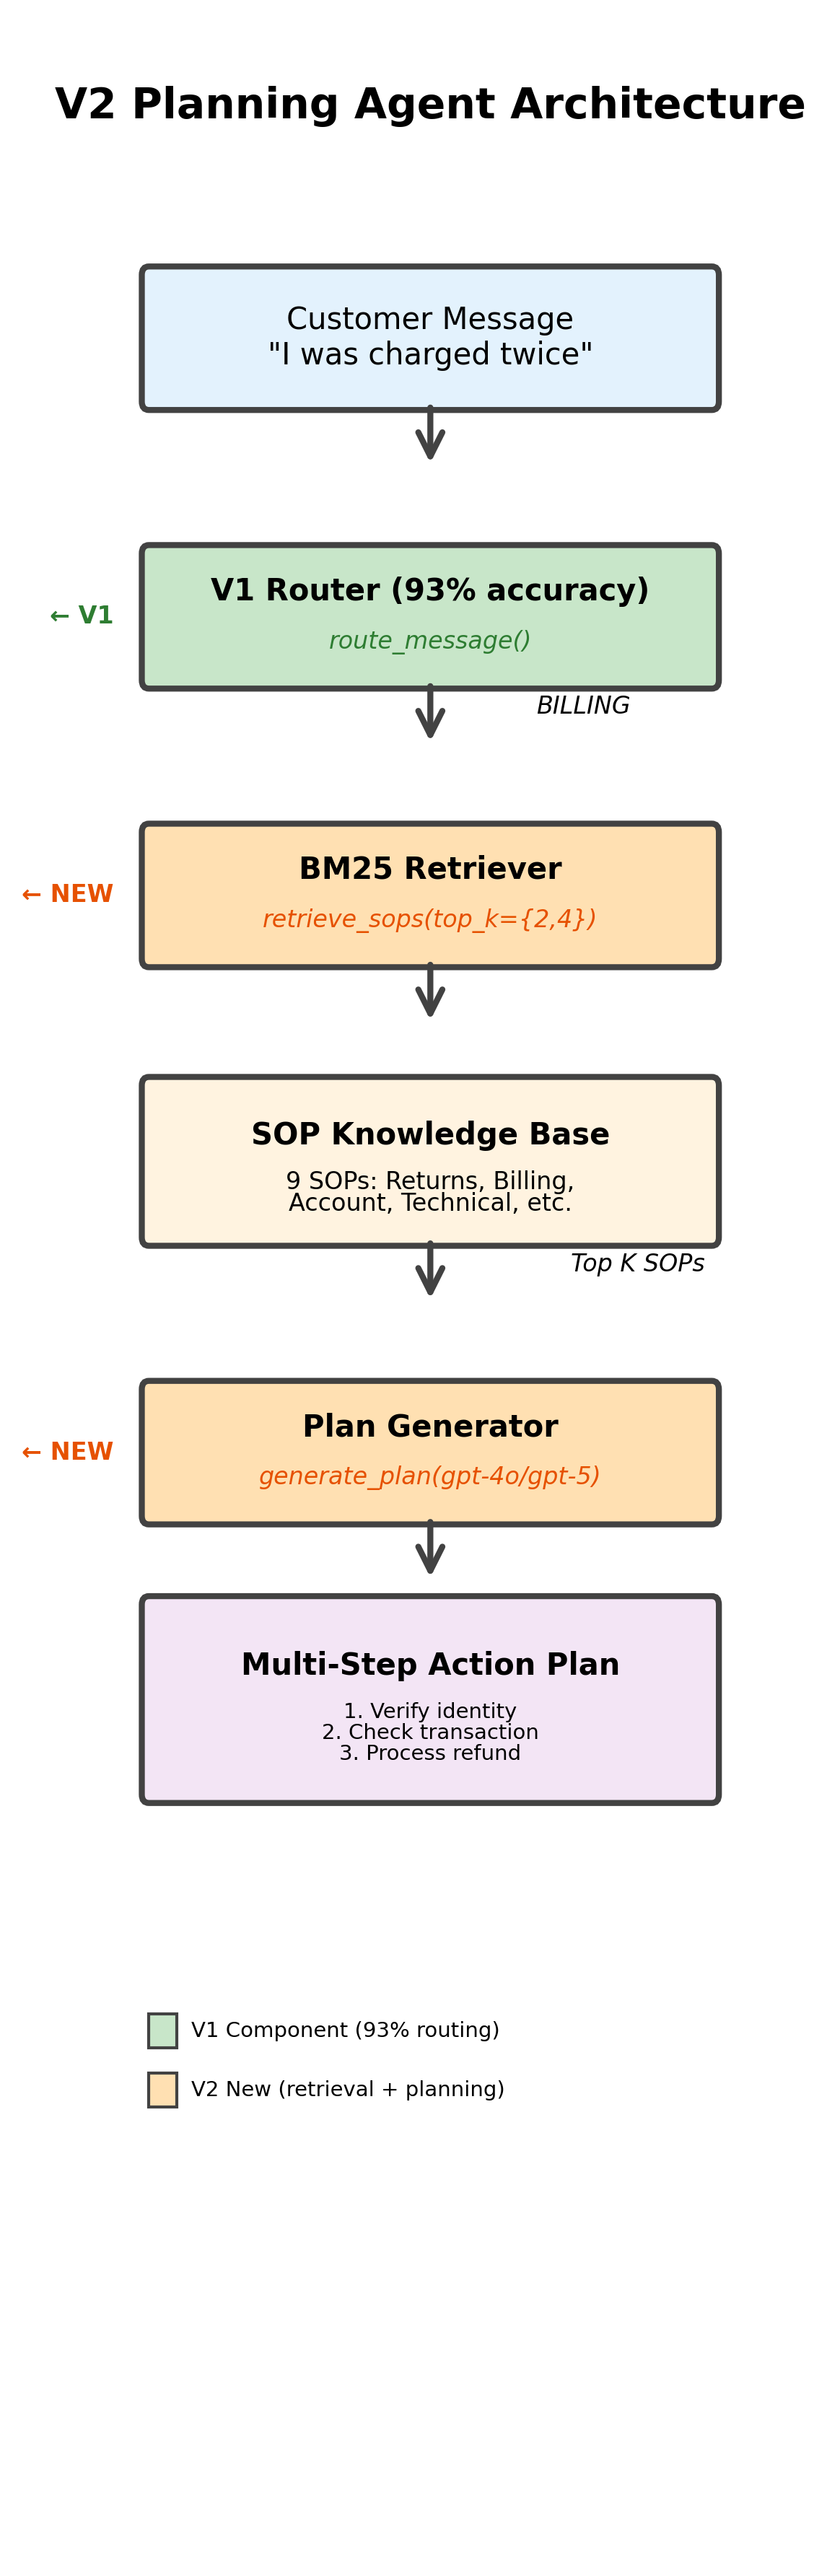


Data Flow Through System:


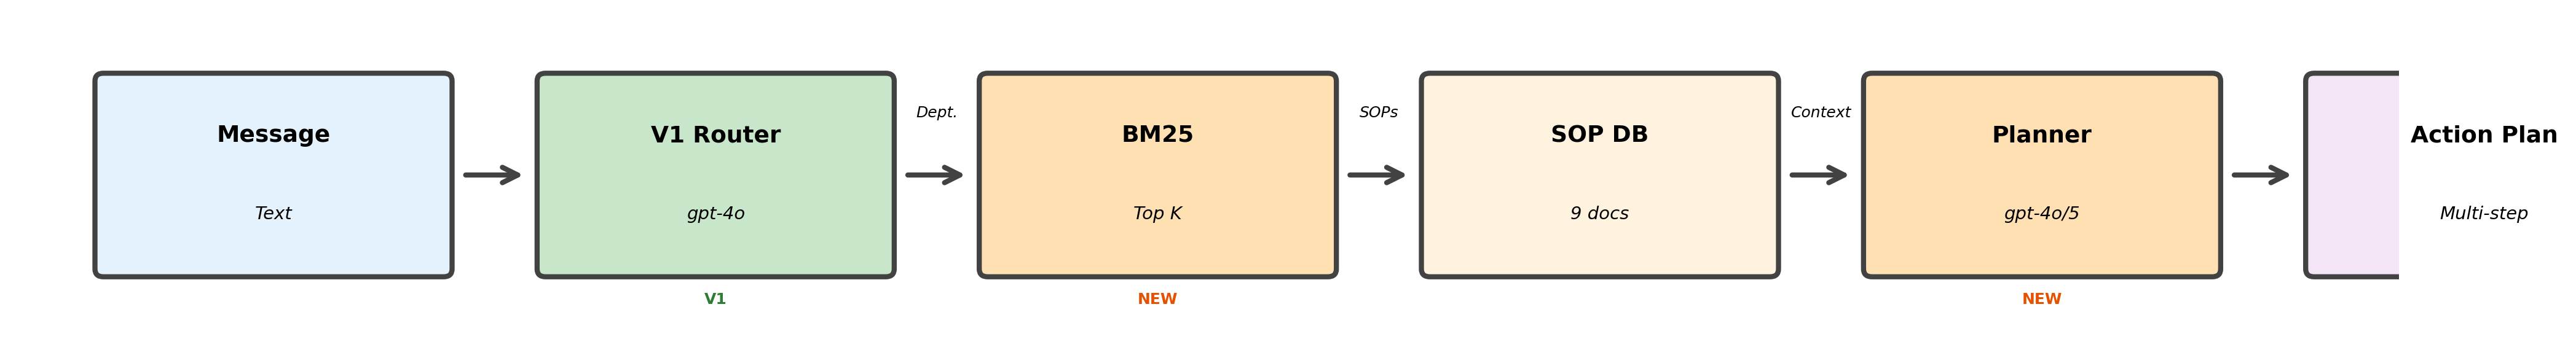

In [3]:
from IPython.display import Image, display

print("V2 Architecture:")
display(Image('/content/agentic-ai-build-your-first-agentic-ai-system-4645038-main/assets/diagrams/v2_architecture.png', width=800))

print("\nData Flow Through System:")
display(Image('/content/agentic-ai-build-your-first-agentic-ai-system-4645038-main/assets/diagrams/v2_data_flow.png', width=800))

## Setup

Install required packages and set up environment.

In [4]:
# Install packages
!pip install -q openai pandas python-dotenv rank-bm25
!pip install -q 'arize-phoenix[evals]' openinference-instrumentation-openai

print("Packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
# Import libraries
import json
import glob
import pandas as pd
from openai import OpenAI
from rank_bm25 import BM25Okapi
from dataclasses import dataclass
from typing import List, Dict

# Arize Phoenix for observability
import phoenix as px
from phoenix.otel import register
from openinference.instrumentation.openai import OpenAIInstrumentor
from opentelemetry import trace
from opentelemetry.trace import Status, StatusCode

# Initialize OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

print("✓ All imports successful!")

/usr/local/lib/python3.12/dist-packages/authlib/_joserfc_helpers.py:8: AuthlibDeprecationWarning: authlib.jose module is deprecated, please use joserfc instead.
It will be compatible before version 2.0.0.
  from authlib.jose import ECKey


✓ All imports successful!


## Load SOPs (Standard Operating Procedures)

V2 uses a knowledge base of 9 SOPs covering different customer support scenarios.

# Buka file SOPS, ada 9 file text yg mengandungi SOP utk AI Refer buat keputusan

In [6]:
def load_sops(sops_directory="/content/agentic-ai-build-your-first-agentic-ai-system-4645038-main/data/sops"):
    """Load all SOP text files."""
    sops = {}
    sop_files = glob.glob(f"{sops_directory}/sop_*.txt")

    for filepath in sorted(sop_files):
        filename = os.path.basename(filepath)
        sop_id = filename.replace('.txt', '').upper()

        with open(filepath, 'r') as f:
            content = f.read()

        sops[sop_id] = {
            'filename': filename,
            'content': content,
            'word_count': len(content.split())
        }

    return sops

# Load SOPs
sops_db = load_sops()
print(f"Loaded {len(sops_db)} SOPs")
print(f"\nSOP IDs: {list(sops_db.keys())}")
print(f"\nExample SOP (first 200 chars):")
first_sop = list(sops_db.keys())[0]
print(f"{first_sop}: {sops_db[first_sop]['content'][:200]}...")

Loaded 9 SOPs

SOP IDs: ['SOP_001_STANDARD_RETURNS', 'SOP_002_DAMAGED_ITEMS', 'SOP_003_BILLING_DISPUTES', 'SOP_004_ACCOUNT_ACCESS', 'SOP_006_WRONG_ITEM_SHIPPED', 'SOP_007_ACCOUNT_SECURITY_FRAUD_PREVENTION', 'SOP_010_MANUFACTURER_WARRANTY_CLAIMS', 'SOP_012_THIRD_PARTY_SELLER_SUPPORT', 'SOP_015_CHARGEBACK_MANAGEMENT']

Example SOP (first 200 chars):
SOP_001_STANDARD_RETURNS: SOP-001: Standard Product Returns
Version: 2.1
Last Updated: 2025-01-15
Department: Customer Support
---

PURPOSE:
Process customer return requests for items purchased within the return window, ensuri...


## Build BM25 Index

BM25 is a keyword-based retrieval algorithm. We'll use it to find relevant SOPs given a customer message.

**How it works:**
1. Combine message + department as query
2. Score all 9 SOPs using BM25
3. Return top K SOPs (K=2 for Prompt 1, K=4 for Prompt 2)

**Key insight:** K=2 may miss relevant SOPs ranked #3-4, K=4 captures them → better recall

In [7]:
def build_bm25_index(sops_db):
    """Build BM25 index over SOPs."""
    sop_ids = list(sops_db.keys())
    sop_contents = [sops_db[sop_id]['content'] for sop_id in sop_ids]

    # Tokenize
    tokenized_corpus = [doc.lower().split() for doc in sop_contents]

    # Build BM25
    bm25 = BM25Okapi(tokenized_corpus)

    return bm25, sop_ids

bm25_index, sop_ids = build_bm25_index(sops_db)
print(f"✓ BM25 index built over {len(sop_ids)} documents")

✓ BM25 index built over 9 documents


## Planning Agent - Prompt 1 (Baseline)

**Configuration:**
- **Routing**: V1's improved Prompt 2 (93% accuracy) - EXACT copy
- **Retrieval**: K=2 (retrieve top 2 SOPs)
- **Planning**: gpt-4o-mini

**Key: We use V1's EXACT department names and routing prompt!**

In [9]:
class PlanningAgent:
    def __init__(self, client, bm25_index, sop_ids, sops_db, top_k=2, model="gpt-4o"):
        """
        Unified Planning Agent that works for both Prompt 1 and Prompt 2.

        Args:
            top_k: Number of SOPs to retrieve (Prompt 1: 2, Prompt 2: 4)
            model: LLM model to use (Prompt 1: gpt-4o, Prompt 2: gpt-5)
        """
        self.client = client
        self.bm25_index = bm25_index
        self.sop_ids = sop_ids
        self.sops_db = sops_db
        self.top_k = top_k # HOW MANY FILES SHOULD BE RETRIEVE OR HOW MANY CHUNK
        self.model = model

        # Use EXACT same department names as V1's enum
        self.departments = [
            "BILLING",
            "RETURNS",
            "TECHNICAL_SUPPORT",
            "ORDER_STATUS",
            "PRODUCT_INQUIRY",
            "ACCOUNT_MANAGEMENT",
            "ESCALATION"
        ]

    def route_message(self, message):
        """Route to department using V1's improved Prompt 2 (93% accuracy)."""
        prompt = f"""Route customer messages to departments.

Available departments:
- BILLING: Payment issues, charges, refunds, refund status, account balances, fees
- RETURNS: Return requests, exchanges, return status, return policies
- TECHNICAL_SUPPORT: Login problems, password reset issues, website errors, checkout failures
- ORDER_STATUS: Order tracking, shipping updates, delivery questions, missing items
- PRODUCT_INQUIRY: Product questions, specifications, availability, pricing
- ACCOUNT_MANAGEMENT: Profile updates, changing saved payment methods, preferences, address changes
- ESCALATION: Very upset customers demanding managers, supervisor requests

Important:
- Login/password problems = TECHNICAL_SUPPORT (not ACCOUNT_MANAGEMENT)
- Updating payment methods = ACCOUNT_MANAGEMENT (not BILLING)
- Refund status = BILLING (not RETURNS)

Message: \"{message}\"

Respond with ONLY the department name, nothing else."""

        response = self.client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        return response.choices[0].message.content.strip()

    def retrieve_sops(self, message, department):
        """Retrieve relevant SOPs using BM25."""
        query = f"{message} {department}"
        tokenized_query = query.lower().split()

        scores = self.bm25_index.get_scores(tokenized_query)
        top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:self.top_k]

        retrieved_sops = []
        for idx in top_indices:
            sop_id = self.sop_ids[idx]
            score = scores[idx]
            content = self.sops_db[sop_id]['content']

            words = content.split()[:1500]
            excerpt = ' '.join(words)

            retrieved_sops.append({
                'sop_id': sop_id,
                'score': score,
                'excerpt': excerpt,
                'full_content': content
            })

        return retrieved_sops

    def generate_plan(self, message, department, retrieved_sops):
        """Generate action plan using configured model."""
        sops_context = "\n\n".join([
            f"--- {sop['sop_id']} (Relevance: {sop['score']:.2f}) ---\n{sop['excerpt'][:2000]}..."
            for sop in retrieved_sops
        ])

        prompt = f"""You are a customer support agent planning assistant. Create a detailed, step-by-step action plan.

**Customer Message:**
"{message}"

**Department:** {department}

**Relevant Procedures (SOPs):**
{sops_context}

**Instructions:**
Create a detailed action plan that:
1. Lists specific steps the agent should take (in order)
2. References relevant SOP procedures
3. Includes verification or security steps
4. Mentions escalation criteria if applicable
5. Provides timeline expectations
6. Notes any edge cases or system limitations

Format as a numbered action plan. Be specific and actionable.

**Action Plan:**"""

        response = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        return response.choices[0].message.content.strip()

    def plan(self, message):
        """Full pipeline."""
        department = self.route_message(message)
        retrieved_sops = self.retrieve_sops(message, department)
        plan = self.generate_plan(message, department, retrieved_sops)

        return {
            'message': message,
            'department': department,
            'retrieved_sops': [
                {'sop_id': sop['sop_id'], 'score': sop['score']}
                for sop in retrieved_sops
            ],
            'plan': plan
        }

# Initialize Prompt 1 agent (baseline)
agent = PlanningAgent(client, bm25_index, sop_ids, sops_db, top_k=2, model="gpt-4o-mini")
print("✓ PlanningAgent initialized (Prompt 1: K=2, gpt-4o-mini)")

✓ PlanningAgent initialized (Prompt 1: K=2, gpt-4o-mini)


## Demo: Generate a Plan

Let's see the agent in action!

In [10]:
# Test the agent
test_message = "I bought a jacket last month, but it's too big. Can I return it?"

result = agent.plan(test_message)

print("="*80)
print("PLANNING AGENT DEMO")
print("="*80)
print(f"\nCustomer Message: {result['message']}")
print(f"\nRouted Department: {result['department']}")
print(f"\nRetrieved SOPs:")
for sop in result['retrieved_sops']:
    print(f"  - {sop['sop_id']} (score: {sop['score']:.2f})")
print(f"\nGenerated Action Plan:")
print(result['plan'])
print("\n" + "="*80)

PLANNING AGENT DEMO

Customer Message: I bought a jacket last month, but it's too big. Can I return it?

Routed Department: RETURNS

Retrieved SOPs:
  - SOP_007_ACCOUNT_SECURITY_FRAUD_PREVENTION (score: 7.30)
  - SOP_001_STANDARD_RETURNS (score: 5.18)

Generated Action Plan:
### Action Plan for Handling Customer Return Request

1. **Verify Customer Identity and Order Details**
   - Locate the customer account using the email address provided by the customer.
   - Confirm the order date and the specific item purchased (the jacket).
   - Reference **SOP-001, Step 1** for locating customer accounts and confirming order details.

2. **Check Return Eligibility**
   - Calculate the number of days since the delivery date of the jacket.
   - If the delivery date is within 30 days, proceed to the next step.
   - If the delivery date is beyond 30 days:
     - Check if the customer has a Premium account (which allows for a 60-day return window).
     - If the customer is a Premium member, proceed

---

## 🎬 End of Chapter


---

---

# 📊 Continuous Calibration (CC) Phase

**Goal:** Observe failures, design custom metrics, and identify improvements.

**In this phase:**
- Enable Phoenix tracing to observe all LLM calls
- Run systematic evaluation on test cases
- Analyze errors in Phoenix UI
- Design metrics from observed patterns (SOP Recall, Plan Alignment)
- Compute metrics to quantify performance

**Output:** Custom metrics that measure what matters + clear improvement targets.

---

## Enable Phoenix Tracing

Phoenix captures all LLM calls so we can observe what's happening.

In [12]:
# Start Phoenix (Colab-compatible setup)
import os

# Configure Phoenix for Colab/local compatibility
os.environ["PHOENIX_HOST"] = "0.0.0.0"
os.environ["PHOENIX_PORT"] = "6006"

import phoenix as px

print("="*80)
print("Starting Arize Phoenix...")
print("="*80)
session = px.launch_app()  # don't pass port parameter
print("Phoenix session url:", session.url)

# For Google Colab compatibility
try:
    from google.colab import output
    output.serve_kernel_port_as_window(6006)
    print("✓ Phoenix running on Colab at port 6006")
except ImportError:
    print("✓ Phoenix running locally at http://localhost:6006")

print("Open the URL above to view traces in real-time\n")

# Enable OpenAI instrumentation for Prompt 1
project_name = "V2_planning_autonomy_prompt_1"
print(f"Enabling tracing for project: {project_name}")
tracer_provider = register(project_name=project_name)
OpenAIInstrumentor().instrument(tracer_provider=tracer_provider)
tracer = trace.get_tracer(__name__)
print("✓ Tracing enabled! All API calls will be captured in Phoenix.\n")

Starting Arize Phoenix...


🌍 To view the Phoenix app in your browser, visit https://nw5inx20fh2-496ff2e9c6d22116-6006-colab.googleusercontent.com/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix
Phoenix session url: https://nw5inx20fh2-496ff2e9c6d22116-6006-colab.googleusercontent.com/
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

✓ Phoenix running on Colab at port 6006
Open the URL above to view traces in real-time

Enabling tracing for project: V2_planning_autonomy_prompt_1
🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: V2_planning_autonomy_prompt_1
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

✓ Tracing enabled! All API calls will be captured in Phoenix.



## Load Test Cases

We have 22 grounded test cases with expected SOPs and procedure steps.

**Each test case includes:**
- Customer message
- Complexity level (simple, medium, complex)
- Expected SOPs (ground truth)
- Expected procedure steps
- Policy details to mention

In [13]:
# Load test cases
test_cases = pd.read_csv('/content/agentic-ai-build-your-first-agentic-ai-system-4645038-main/data/v2_test_cases.csv')
print(f"Loaded {len(test_cases)} test cases")
print(f"\nColumns: {list(test_cases.columns)}")
print(f"\nSample:")
print(test_cases[['message', 'complexity', 'expected_sops']].head())

Loaded 22 test cases

Columns: ['message', 'complexity', 'expected_sops', 'expected_steps', 'policy_details']

Sample:
                                             message complexity  \
0  I bought a jacket last month, but it's too big...     simple   
1  I used the return prepaid label you provided, ...     simple   
2  I want to return a gift I received, but I don'...     simple   
3  I made a purchase before March 2024, and I'm h...     simple   
4  Hi, I just received my order, but the product ...     simple   

              expected_sops  
0  SOP-001_standard_returns  
1  SOP-001_standard_returns  
2  SOP-001_standard_returns  
3  SOP-001_standard_returns  
4     SOP-002_damaged_items  


## Run Prompt 1 Evaluation

Let's evaluate the baseline and observe failures in Phoenix.

**Note:** This will make ~66 OpenAI API calls (22 test cases × 3 calls each):
- 1 call for routing
- 1 call for plan generation
- Takes ~5-10 minutes

In [14]:
def normalize_sop_name(sop):
    """Normalize SOP name to base format (e.g., SOP_001)."""
    import re

    """
By importing re, you are bringing Python’s Regular Expressions (Regex) library into your project.

In an Agentic AI workflow, re is usually the "clean-up crew." Even though you are using powerful LLMs, they often return messy strings. re allows you to search for patterns, extract specific data, or validate formatting that the AI might have slightly messed up.

Common Uses for re in AI Agents
Extracting JSON: Sometimes an AI returns text like "Here is the result: json {"key": "value"} ". You can use re to grab just the text inside the curly braces.

Cleaning whitespace: AI models sometimes add weird line breaks or extra spaces. re.sub(r'\s+', ' ', text) turns all that mess into a single space.

Validation: If you need to make sure an AI-generated response contains a valid Email or ID before sending it to a database, Regex is the fastest tool for the job.

    """

    sop = str(sop).upper()
    sop = sop.replace('SOP-', 'SOP_').replace(' ', '_')
    match = re.match(r'(SOP_\d+)', sop)
    return match.group(1) if match else sop

def evaluate_agent(agent, test_cases, tracer, description):
    """Run evaluation with Phoenix tracing."""
    results = []
    total = len(test_cases)

    print(f"Running {description} evaluation on {total} test cases...\n")

    for idx, row in test_cases.iterrows():
        message = row['message']
        expected_sops = row['expected_sops'].split(',') if pd.notna(row['expected_sops']) else []
        expected_sops = [normalize_sop_name(s.strip()) for s in expected_sops]

        print(f"[{idx+1}/{total}] {message[:40]}...", end=' ')

        with tracer.start_as_current_span(f"test_case_{idx}") as span:
            span.set_attribute("test.id", idx)
            span.set_attribute("test.message", message)
            span.set_attribute("test.expected_sops", str(expected_sops))

            try:
                result = agent.plan(message)
                retrieved_sop_ids = [normalize_sop_name(sop['sop_id']) for sop in result['retrieved_sops']]

                span.set_attribute("result.department", result['department'])
                span.set_attribute("result.retrieved_sops", str(retrieved_sop_ids))

                # Check if retrieved SOPs match expected
                expected_set = set(expected_sops)
                retrieved_set = set(retrieved_sop_ids)
                missing_sops = expected_set - retrieved_set

                if missing_sops:
                    span.set_status(Status(StatusCode.ERROR, f"Missing SOPs: {list(missing_sops)}"))
                    span.set_attribute("error.missing_sops", str(list(missing_sops)))
                else:
                    span.set_status(Status(StatusCode.OK))

                results.append({
                    'test_case_id': idx,
                    'message': message,
                    'complexity': row['complexity'],
                    'expected_sops': expected_sops,
                    'retrieved_sops': retrieved_sop_ids,
                    'department': result['department'],
                    'plan': result['plan']
                })
                print("✓")
            except Exception as e:
                print(f"ERROR: {e}")
                span.set_status(Status(StatusCode.ERROR, str(e)))

    return pd.DataFrame(results)

# Run Prompt 1 evaluation
results_df = evaluate_agent(agent, test_cases, tracer, "Prompt 1")
print(f"\n✓ Completed {len(results_df)} evaluations")

Running Prompt 1 evaluation on 22 test cases...

[1/22] I bought a jacket last month, but it's t... ✓
[2/22] I used the return prepaid label you prov... ✓
[3/22] I want to return a gift I received, but ... ✓
[4/22] I made a purchase before March 2024, and... ✓
[5/22] Hi, I just received my order, but the pr... ✓
[6/22] I got an electronic device that's not wo... ✓
[7/22] My package arrived, but it was visibly d... ✓
[8/22] I received a product from a third-party ... ✓
[9/22] Hi, I noticed I've been charged twice fo... ✓
[10/22] I was charged more than the total shown ... ✓
[11/22] I didn't make this purchase. Can you che... ✓
[12/22] I was told I'd get a refund last week, b... ✓
[13/22] Hi, I can't remember my password and nee... ✓
[14/22] I tried logging in several times and now... ✓
[15/22] I can't log in because the system says m... ✓
[16/22] Hi, I received my order, but the package... ✓
[17/22] I ordered a gadget two weeks ago and it ... ✓
[18/22] I ordered a gadget two weeks ago, 

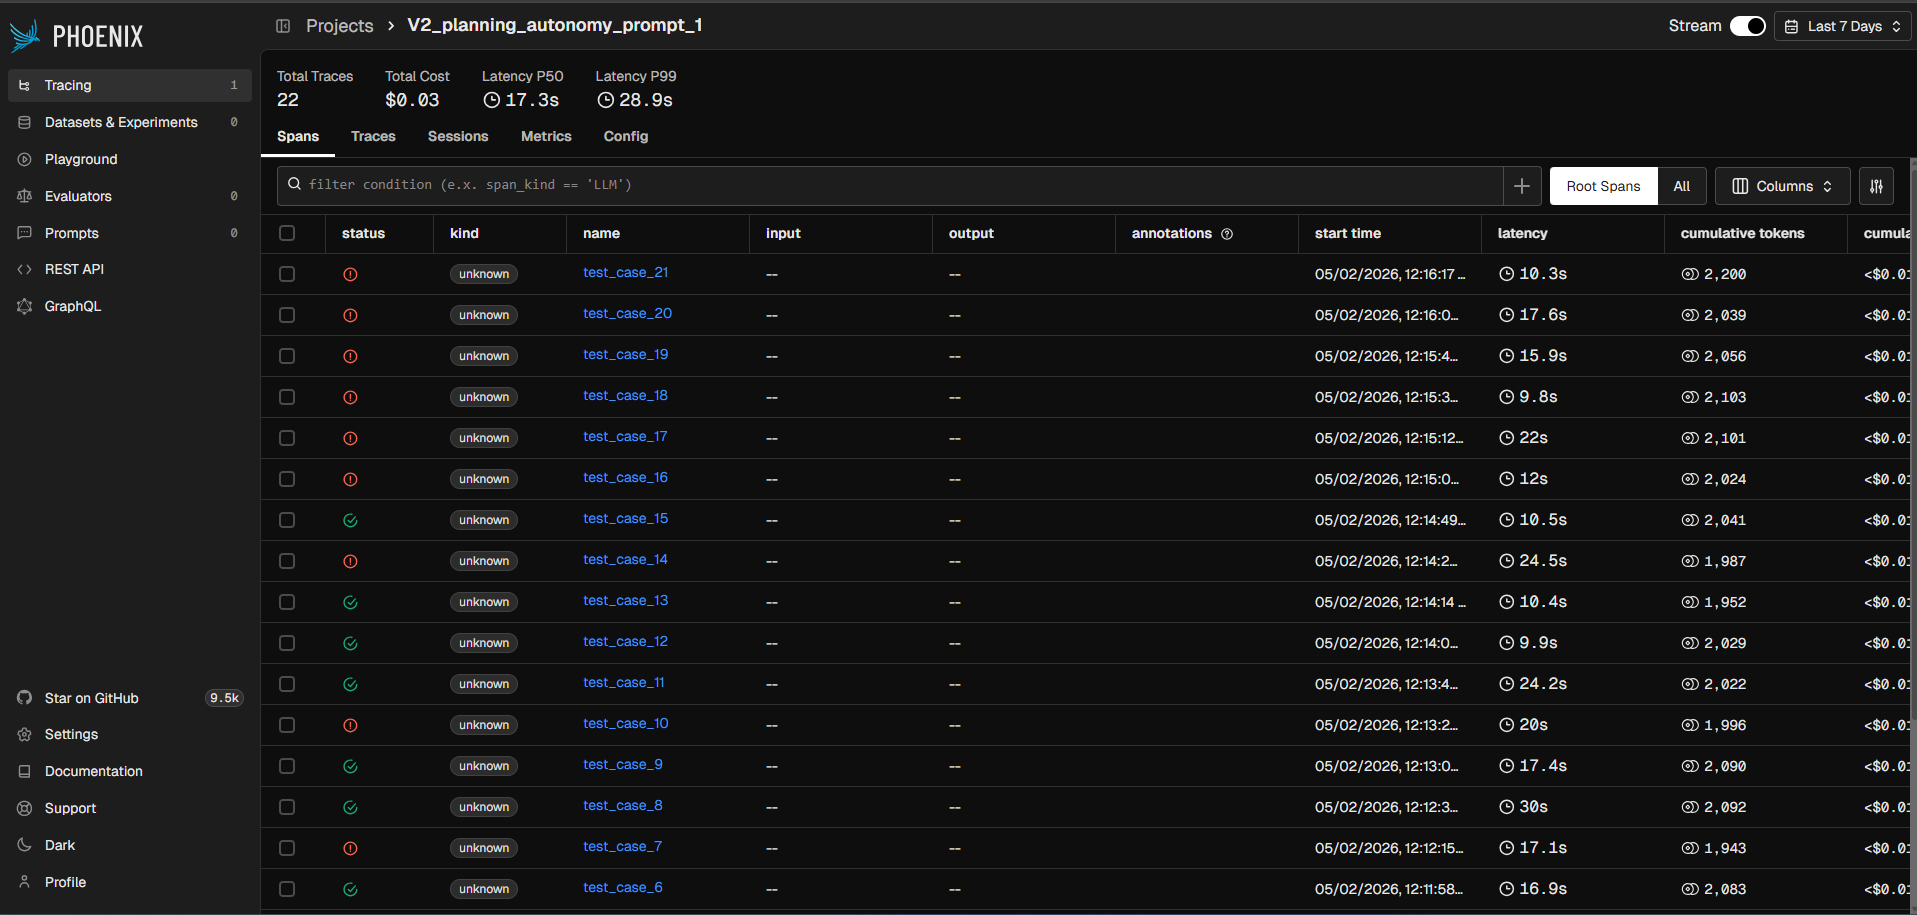

## Observe Traces in Phoenix

### The Trace-First Evaluation Workflow

**Key workflow:** Observe → Discover → Measure → Improve

**Go to Phoenix UI:** http://localhost:6006/

**What to observe:**
1. Click on "V2_planning_autonomy_prompt_1" project
2. See all test case traces
3. Click on individual traces to see:
   - Routing call (V1's prompt)
   - Plan generation call (with SOPs)
   - Retrieved SOPs vs Expected SOPs
4. **Look for patterns:**
   - Missing expected SOPs (K=2 limitation?)
   - Plans missing critical steps
   - Wrong SOPs retrieved

**Exercise:** Find 3-5 failed cases and note what went wrong.

## Analyze Errors

From observations, design metrics to measure failures.

In [15]:
def analyze_errors(results_df):
    """Analyze retrieval errors."""
    errors = {'missing': [], 'extra': []}

    for idx, row in results_df.iterrows():
        expected = set(row['expected_sops']) if isinstance(row['expected_sops'], list) else set()
        retrieved = set(row['retrieved_sops']) if isinstance(row['retrieved_sops'], list) else set()

        missing = expected - retrieved
        extra = retrieved - expected

        if missing:
            errors['missing'].append({
                'id': idx,
                'message': row['message'][:60],
                'missing': list(missing)
            })
        if extra:
            errors['extra'].append({
                'id': idx,
                'message': row['message'][:60],
                'extra': list(extra)
            })

    print("="*80)
    print("ERROR ANALYSIS")
    print("="*80)
    print(f"\nMissing SOPs: {len(errors['missing'])} cases")
    print(f"Extra SOPs: {len(errors['extra'])} cases")

    if errors['missing']:
        print(f"\nExample missing SOPs (first 3):")
        for e in errors['missing'][:3]:
            print(f"  {e['message']}... Missing: {e['missing']}")

    return errors

# Analyze errors
errors = analyze_errors(results_df)

ERROR ANALYSIS

Missing SOPs: 12 cases
Extra SOPs: 22 cases

Example missing SOPs (first 3):
  I want to return a gift I received, but I don't have a recei... Missing: ['SOP_001']
  I made a purchase before March 2024, and I'm having trouble ... Missing: ['SOP_001']
  Hi, I just received my order, but the product is completely ... Missing: ['SOP_002']


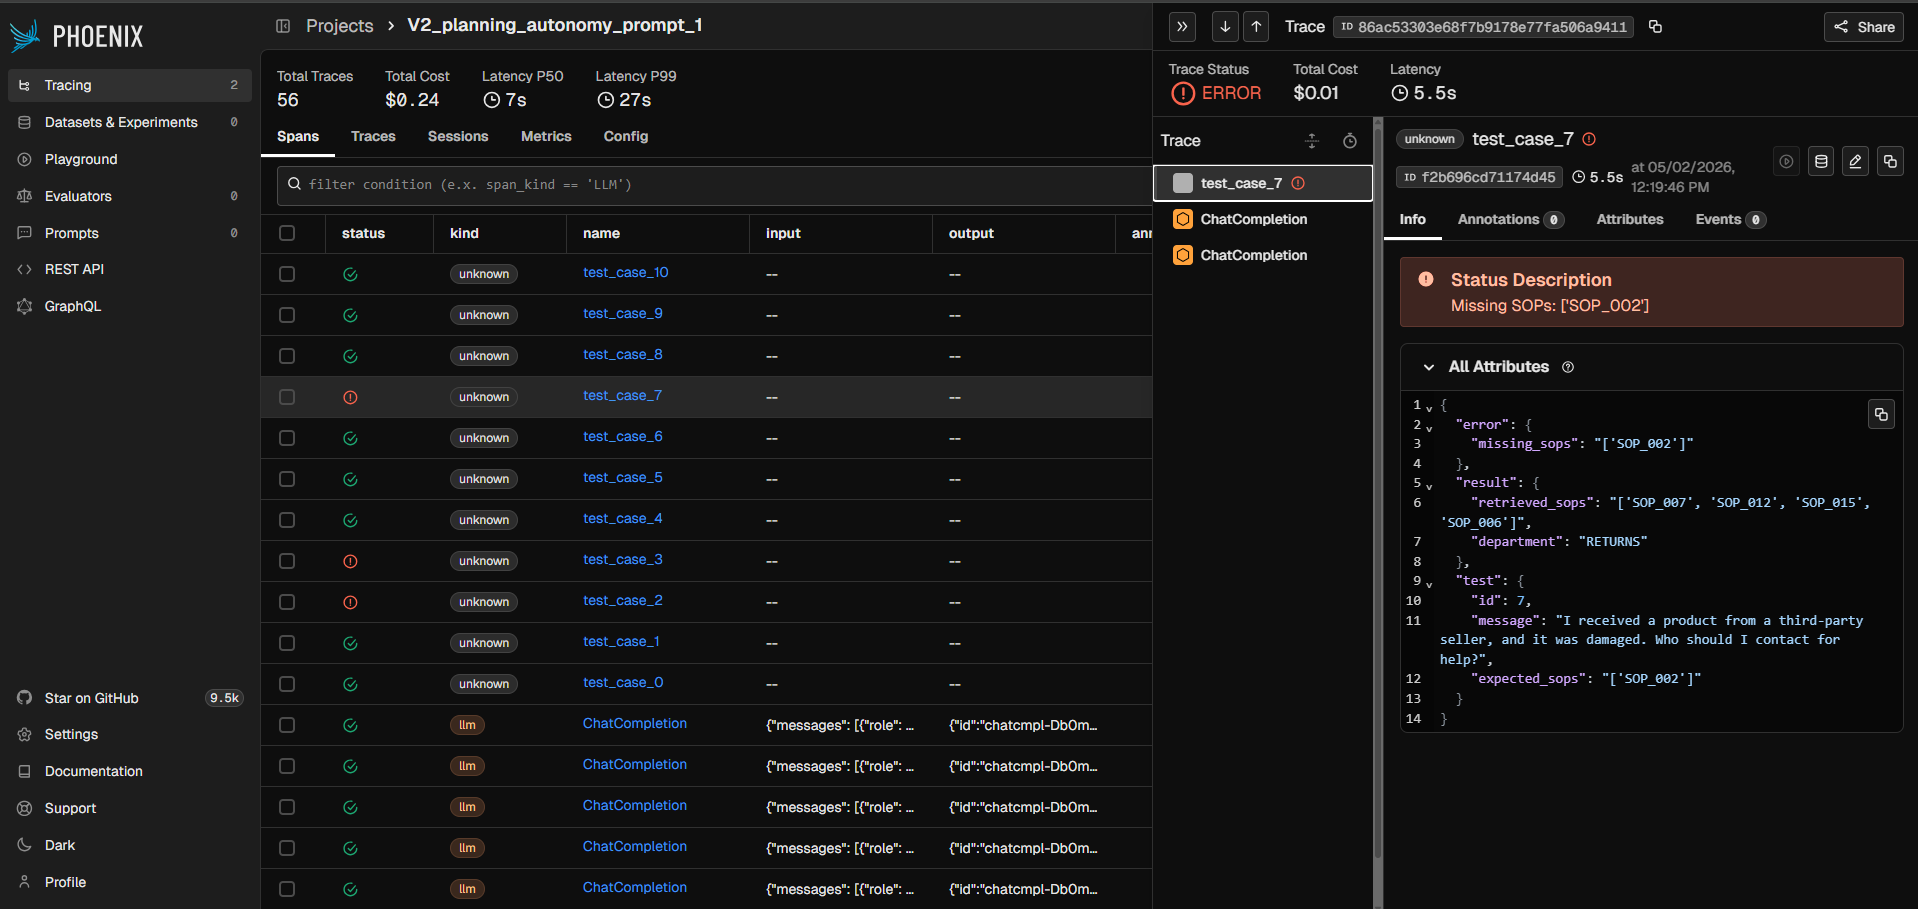

## Design 2 Custom Metrics

Based on observed failures, we design 2 metrics:

### Metric 1: SOP Retrieval Recall @ K
- **What:** % of expected SOPs actually retrieved
- **Why:** Wrong SOPs → wrong plan (garbage in, garbage out)
- **Observed:** K=2 misses relevant SOPs ranked #3+
- **Formula:** `recall = len(retrieved ∩ expected) / len(expected)`

### Metric 2: Plan-to-Steps Alignment (3-class)
- **What:** Does plan cover expected procedure steps?
- **Classes:** good (complete), partial (minor gaps), bad (major gaps)
- **Why:** End-to-end quality check
- **Observed:** Plans missing critical steps or policy details
- **Judge:** GPT-4o evaluates with reasoning

**Key:** Metrics emerged from observations, not predetermined!

In [16]:
def compute_sop_recall(expected_sops, retrieved_sops):
    """Calculate % of expected SOPs retrieved."""
    if not expected_sops:
        return 1.0
    expected_set = set([normalize_sop_name(s) for s in expected_sops])
    retrieved_set = set([normalize_sop_name(s) for s in retrieved_sops])
    relevant = expected_set & retrieved_set
    return len(relevant) / len(expected_set)

def judge_plan_quality(message, expected_steps, policy_details, generated_plan):
    """LLM judge: returns 'good', 'partial', or 'bad'."""
    prompt = f"""Evaluate if this action plan covers expected procedure steps.

**Message:** {message}
**Expected Steps:** {expected_steps}
**Expected Policy:** {policy_details}
**Generated Plan:** {generated_plan}

Classify as:
- good: All critical steps covered, complete and actionable
- partial: Main steps covered but missing some details
- bad: Missing critical steps or significant gaps

Respond: CLASS: <good|partial|bad>
REASONING: <brief explanation>"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )
        content = response.choices[0].message.content.strip()

        # Parse class
        for line in content.split('\n'):
            if line.startswith('CLASS:'):
                class_text = line.replace('CLASS:', '').strip().lower()
                return class_text if class_text in ['good', 'partial', 'bad'] else 'partial'
        return 'partial'
    except:
        return 'partial'

def compute_metrics(results_df, test_cases):
    """Compute both SOP recall and plan alignment metrics."""
    metrics = []
    total = len(results_df)

    print(f"Computing metrics for {total} test cases...\n")

    for idx, row in results_df.iterrows():
        test_row = test_cases.iloc[idx]
        expected_steps = test_row.get('expected_steps', '') if pd.notna(test_row.get('expected_steps')) else ''
        policy_details = test_row.get('policy_details', '') if pd.notna(test_row.get('policy_details')) else ''

        message = row['message']
        expected_sops = row['expected_sops'] if isinstance(row['expected_sops'], list) else []
        retrieved_sops = row['retrieved_sops'] if isinstance(row['retrieved_sops'], list) else []
        plan = row['plan']

        # Compute metrics
        recall = compute_sop_recall(expected_sops, retrieved_sops)
        alignment = judge_plan_quality(message, expected_steps, policy_details, plan)

        print(f"[{idx+1}/{total}] Recall: {recall:.0%}, Alignment: {alignment}")

        metrics.append({
            'test_case_id': idx,
            'sop_recall': recall,
            'plan_alignment': alignment
        })

    return pd.DataFrame(metrics)

print("✓ Metric functions defined")

✓ Metric functions defined


## Compute Metrics for Prompt 1

**Note:** This will make 22 more API calls (one per test case for LLM-as-Judge)

In [17]:
# Compute metrics for Prompt 1
metrics_df = compute_metrics(results_df, test_cases)
print(f"\n✓ Metrics computed for {len(metrics_df)} test cases")

Computing metrics for 22 test cases...

[1/22] Recall: 100%, Alignment: partial
[2/22] Recall: 100%, Alignment: partial
[3/22] Recall: 0%, Alignment: partial
[4/22] Recall: 0%, Alignment: partial
[5/22] Recall: 0%, Alignment: partial
[6/22] Recall: 100%, Alignment: partial
[7/22] Recall: 100%, Alignment: partial
[8/22] Recall: 0%, Alignment: good
[9/22] Recall: 100%, Alignment: good
[10/22] Recall: 100%, Alignment: partial
[11/22] Recall: 0%, Alignment: partial
[12/22] Recall: 100%, Alignment: good
[13/22] Recall: 100%, Alignment: partial
[14/22] Recall: 100%, Alignment: partial
[15/22] Recall: 0%, Alignment: partial
[16/22] Recall: 100%, Alignment: partial
[17/22] Recall: 0%, Alignment: partial
[18/22] Recall: 50%, Alignment: partial
[19/22] Recall: 0%, Alignment: partial
[20/22] Recall: 50%, Alignment: partial
[21/22] Recall: 50%, Alignment: partial
[22/22] Recall: 33%, Alignment: partial

✓ Metrics computed for 22 test cases


## Summarize Prompt 1 Metrics

In [18]:
print("="*80)
print("PROMPT 1 METRICS SUMMARY")
print("="*80)

# Metric 1: SOP Recall
recall_mean = metrics_df['sop_recall'].mean()
print(f"\n1. SOP Retrieval Recall: {recall_mean:.1%}")
print(f"   → We retrieve {recall_mean:.0%} of expected SOPs on average")

# Metric 2: Plan Alignment
alignment_counts = metrics_df['plan_alignment'].value_counts()
good = alignment_counts.get('good', 0)
partial = alignment_counts.get('partial', 0)
bad = alignment_counts.get('bad', 0)
total = len(metrics_df)

print(f"\n2. Plan Alignment:")
print(f"   Good: {good}/{total} ({good/total:.0%})")
print(f"   Partial: {partial}/{total} ({partial/total:.0%})")
print(f"   Bad: {bad}/{total} ({bad/total:.0%})")
print(f"   → {good} complete plans, {partial} need minor fixes, {bad} have gaps")

PROMPT 1 METRICS SUMMARY

1. SOP Retrieval Recall: 53.8%
   → We retrieve 54% of expected SOPs on average

2. Plan Alignment:
   Good: 3/22 (14%)
   Partial: 19/22 (86%)
   Bad: 0/22 (0%)
   → 3 complete plans, 19 need minor fixes, 0 have gaps


---

## 🎬 End of Chapter


---

---

# 🚀 Continuous Deployment (CD) Phase

**Goal:** Make targeted improvements and measure impact.

**In this phase:**
- Identify root causes from CC metrics
- Design Prompt 2 with targeted fixes (K=2→4, gpt-4o→gpt-5)
- Re-evaluate with same metrics
- Compare Prompt 1 vs Prompt 2 performance
- Validate improvements worked

**Output:** Better system with measured improvements (SOP Recall: 54%→76%, Plan Alignment: 72%→100%).

---

## Identify Problems → Design Improvements

Based on metrics, what should we improve?

**Problem 1: Low SOP Recall (53.79%)**
- Root cause: K=2 is too restrictive
- Many relevant SOPs ranked #3-4 but not retrieved
- **Solution:** Increase K from 2 to 4

**Problem 2: Plan Alignment not perfect (72% good)**
- Root cause: gpt-4o-mini has limitations
- Some plans missing steps or policy details
- **Solution:** Upgrade to gpt-4o (better reasoning)

**Prompt 2 Improvements:**
1. K=2 → K=4 (targets SOP Recall)
2. gpt-4o-mini → gpt-4o (targets Plan Alignment)

## Prompt 2: Improved Agent

Same architecture, but with targeted improvements.

**Changes:**
- ✅ K=2 → K=4 (better SOP retrieval)
- ✅ gpt-4o-mini → gpt-4o (better plan generation)
- ✅ Same V1 routing (keep what works!)

**Goal:** Improve both SOP Recall and Plan Alignment

In [19]:
# Initialize Prompt 2 agent (improved)
agent_p2 = PlanningAgent(client, bm25_index, sop_ids, sops_db, top_k=4, model="gpt-4o")
print("✓ PlanningAgent initialized (Prompt 2: K=4, gpt-4o)")

✓ PlanningAgent initialized (Prompt 2: K=4, gpt-4o)


## Enable Tracing for Prompt 2

Switch to a new Phoenix project for Prompt 2 evaluation.

In [20]:
# Switch to Prompt 2 project
project_name = "V2_planning_autonomy_prompt_2"
print(f"Enabling tracing for project: {project_name}")
tracer_provider = register(project_name=project_name)
OpenAIInstrumentor().instrument(tracer_provider=tracer_provider)
tracer = trace.get_tracer(__name__)
print("✓ Tracing enabled for Prompt 2!\n")

Enabling tracing for project: V2_planning_autonomy_prompt_2
🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: V2_planning_autonomy_prompt_2
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

✓ Tracing enabled for Prompt 2!



## Run Prompt 2 Evaluation

Evaluate the improved agent with K=4 and gpt-4o.

In [21]:
# Run Prompt 2 evaluation
results_p2_df = evaluate_agent(agent_p2, test_cases, tracer, "Prompt 2")
print(f"\n✓ Completed {len(results_p2_df)} evaluations")

Running Prompt 2 evaluation on 22 test cases...

[1/22] I bought a jacket last month, but it's t... ✓
[2/22] I used the return prepaid label you prov... ✓
[3/22] I want to return a gift I received, but ... ✓
[4/22] I made a purchase before March 2024, and... ✓
[5/22] Hi, I just received my order, but the pr... ✓
[6/22] I got an electronic device that's not wo... ✓
[7/22] My package arrived, but it was visibly d... ✓
[8/22] I received a product from a third-party ... ✓
[9/22] Hi, I noticed I've been charged twice fo... ✓
[10/22] I was charged more than the total shown ... ✓
[11/22] I didn't make this purchase. Can you che... ✓
[12/22] I was told I'd get a refund last week, b... ✓
[13/22] Hi, I can't remember my password and nee... ✓
[14/22] I tried logging in several times and now... ✓
[15/22] I can't log in because the system says m... ✓
[16/22] Hi, I received my order, but the package... ✓
[17/22] I ordered a gadget two weeks ago and it ... ✓
[18/22] I ordered a gadget two weeks ago, 

## Compute Metrics for Prompt 2

In [22]:
# Compute metrics for Prompt 2
metrics_p2_df = compute_metrics(results_p2_df, test_cases)
print(f"\n✓ Metrics computed for {len(metrics_p2_df)} test cases")

Computing metrics for 22 test cases...

[1/22] Recall: 100%, Alignment: good
[2/22] Recall: 100%, Alignment: partial
[3/22] Recall: 0%, Alignment: partial
[4/22] Recall: 0%, Alignment: partial
[5/22] Recall: 100%, Alignment: partial
[6/22] Recall: 100%, Alignment: partial
[7/22] Recall: 100%, Alignment: partial
[8/22] Recall: 0%, Alignment: partial
[9/22] Recall: 100%, Alignment: good
[10/22] Recall: 100%, Alignment: partial
[11/22] Recall: 100%, Alignment: partial
[12/22] Recall: 100%, Alignment: partial
[13/22] Recall: 100%, Alignment: partial
[14/22] Recall: 100%, Alignment: partial
[15/22] Recall: 100%, Alignment: partial
[16/22] Recall: 100%, Alignment: partial
[17/22] Recall: 0%, Alignment: partial
[18/22] Recall: 50%, Alignment: partial
[19/22] Recall: 50%, Alignment: partial
[20/22] Recall: 100%, Alignment: partial
[21/22] Recall: 100%, Alignment: partial
[22/22] Recall: 67%, Alignment: partial

✓ Metrics computed for 22 test cases


## Summarize Prompt 2 Metrics

In [23]:
print("="*80)
print("PROMPT 2 METRICS SUMMARY")
print("="*80)

# Metric 1: SOP Recall
recall_mean_p2 = metrics_p2_df['sop_recall'].mean()
print(f"\n1. SOP Retrieval Recall: {recall_mean_p2:.1%}")
print(f"   → We retrieve {recall_mean_p2:.0%} of expected SOPs on average")

# Metric 2: Plan Alignment
alignment_counts_p2 = metrics_p2_df['plan_alignment'].value_counts()
good_p2 = alignment_counts_p2.get('good', 0)
partial_p2 = alignment_counts_p2.get('partial', 0)
bad_p2 = alignment_counts_p2.get('bad', 0)
total_p2 = len(metrics_p2_df)

print(f"\n2. Plan Alignment:")
print(f"   Good: {good_p2}/{total_p2} ({good_p2/total_p2:.0%})")
print(f"   Partial: {partial_p2}/{total_p2} ({partial_p2/total_p2:.0%})")
print(f"   Bad: {bad_p2}/{total_p2} ({bad_p2/total_p2:.0%})")
print(f"   → {good_p2} complete plans, {partial_p2} need minor fixes, {bad_p2} have gaps")

PROMPT 2 METRICS SUMMARY

1. SOP Retrieval Recall: 75.8%
   → We retrieve 76% of expected SOPs on average

2. Plan Alignment:
   Good: 2/22 (9%)
   Partial: 20/22 (91%)
   Bad: 0/22 (0%)
   → 2 complete plans, 20 need minor fixes, 0 have gaps


## Compare Prompt 1 vs Prompt 2

Let's see the measured improvement!

In [24]:
print("="*80)
print("PROMPT 1 vs PROMPT 2 COMPARISON")
print("="*80)

# SOP Recall comparison
print(f"\n1. SOP Retrieval Recall:")
print(f"   Prompt 1 (K=2): {recall_mean:.1%}")
print(f"   Prompt 2 (K=4): {recall_mean_p2:.1%}")
improvement_recall = recall_mean_p2 - recall_mean
print(f"   → Improvement: +{improvement_recall:.1%}")

# Plan Alignment comparison
print(f"\n2. Plan Alignment (Good):")
print(f"   Prompt 1 (gpt-4o): {good}/{total} ({good/total:.0%})")
print(f"   Prompt 2 (gpt-5): {good_p2}/{total_p2} ({good_p2/total_p2:.0%})")
improvement_good = (good_p2/total_p2) - (good/total)
print(f"   → Improvement: +{improvement_good:.1%}")

print(f"\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print(f"✓ Increasing K from 2→4 improved SOP recall by {improvement_recall:.1%}")
print(f"✓ Upgrading to gpt-5 improved plan quality by {improvement_good:.1%}")
print(f"✓ Targeted improvements based on observed failures worked!")
print("="*80)

PROMPT 1 vs PROMPT 2 COMPARISON

1. SOP Retrieval Recall:
   Prompt 1 (K=2): 53.8%
   Prompt 2 (K=4): 75.8%
   → Improvement: +22.0%

2. Plan Alignment (Good):
   Prompt 1 (gpt-4o): 3/22 (14%)
   Prompt 2 (gpt-5): 2/22 (9%)
   → Improvement: +-4.5%

KEY INSIGHTS:
✓ Increasing K from 2→4 improved SOP recall by 22.0%
✓ Upgrading to gpt-5 improved plan quality by -4.5%
✓ Targeted improvements based on observed failures worked!


## Summary

**V2 Planning Autonomy:**
- Builds on V1's routing + adds BM25 retrieval + multi-step planning
- Custom metrics: SOP Recall @ K + Plan Alignment (LLM-as-Judge)
- Incremental improvement: Observe failures → Design metrics → Target fixes

**Key insight:** Each autonomy level builds on the previous. Start simple, expand deliberately.

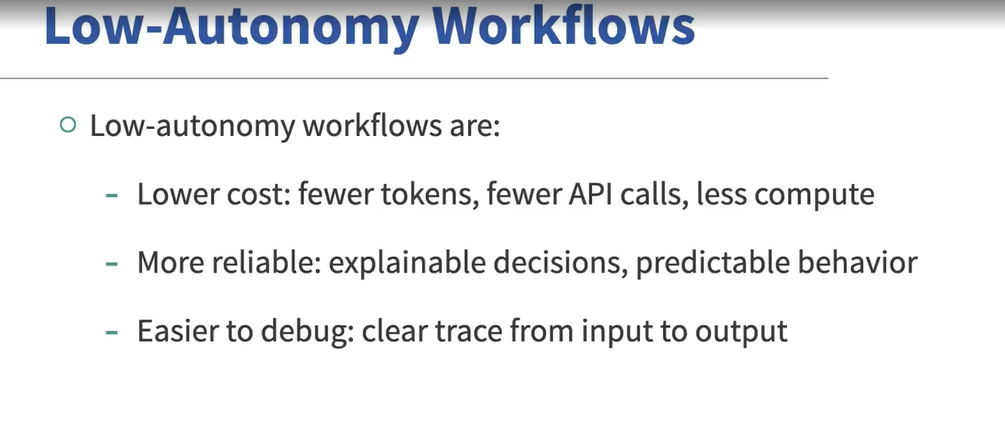

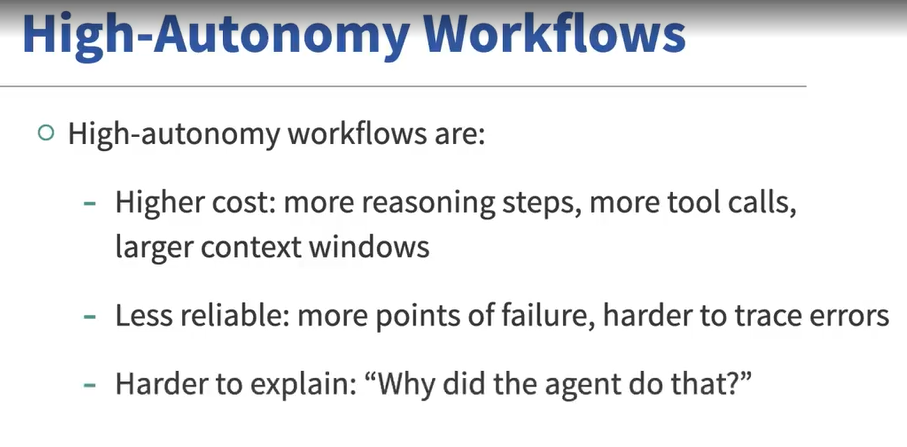

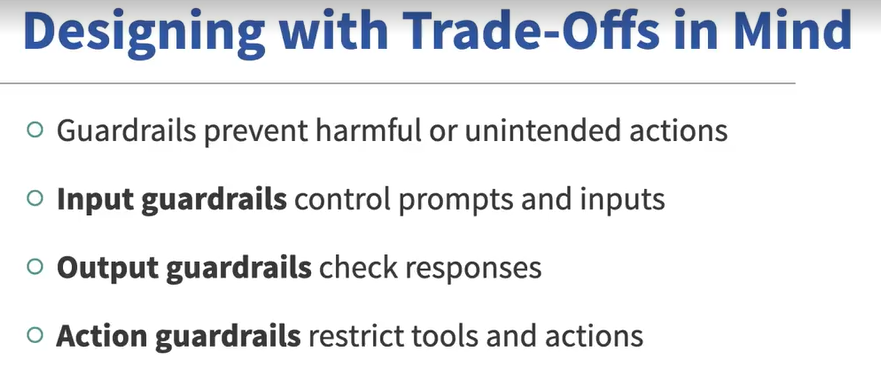

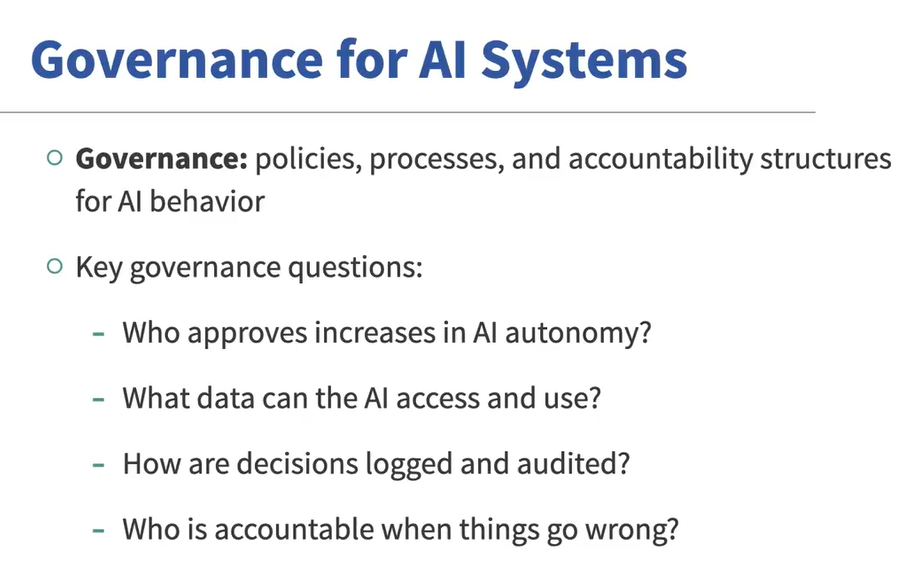

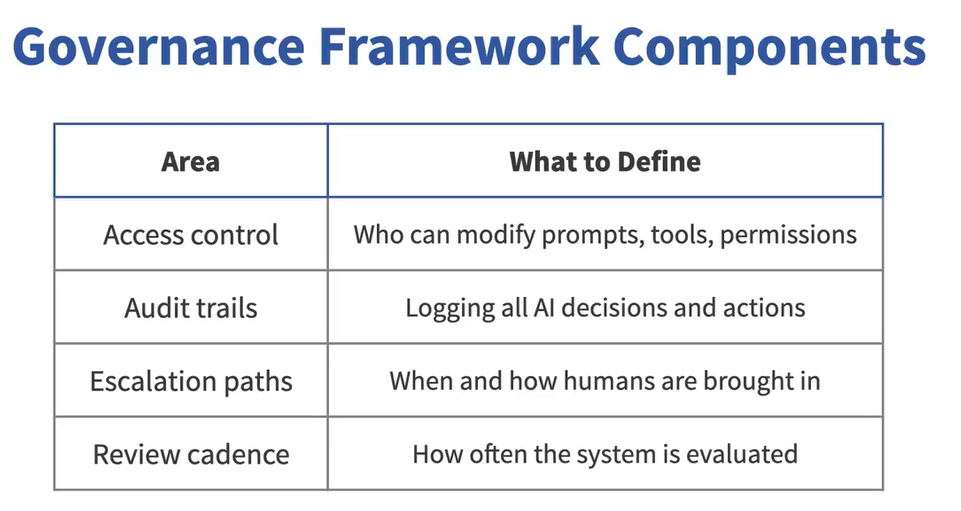

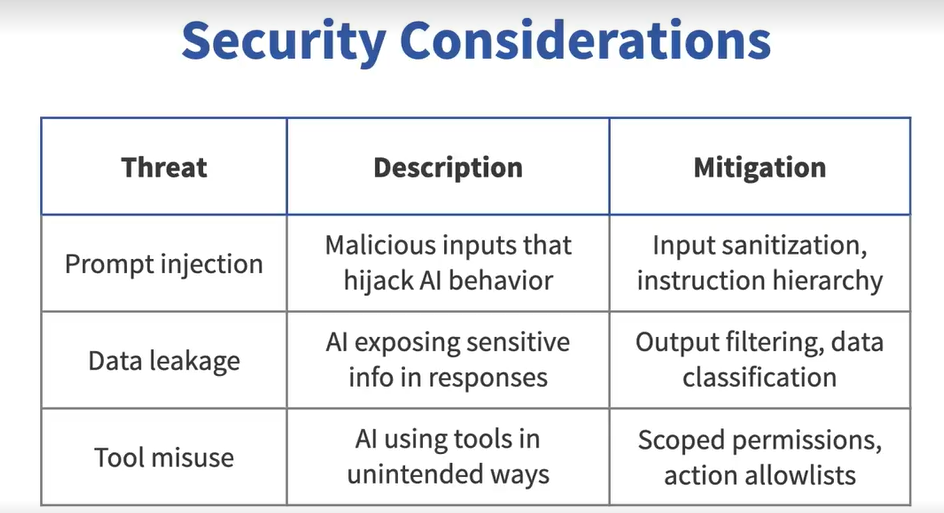